In [1]:
import sys
import os

sys.path.append("..")
sys.path.append("../..")
sys.path.append("../../..")

In [2]:
os.makedirs("./logs/ctr_only/", exist_ok=True)
os.makedirs("./figs/env/", exist_ok=True)
os.makedirs("./figs/exp/ctr_only/", exist_ok=True)

In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import sklearn

from experiment.utils.utils import logit

from typing import Literal

In [4]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Environment Sampling

In [5]:
NUM_AUCTIONS = 1000

In [6]:
wp_sigma = 1.
wp_mean = 100

def generate_wp(seed, num_aucs, rng):
    np.random.seed(seed)
    wp = wp_mean * rng.lognormal(-wp_sigma**2, wp_sigma, num_aucs)
    return wp

In [7]:
CTR_WEIGHTS = np.array([0.6, 0.2, 0.2])
CTR_MEANS = np.array([-3, -2.5, -1])
CTR_SIGMAS = np.array([0.3, 0.3, 0.4])

CVR_WEIGHTS = np.array([0.6, 0.4])
CVR_MEANS = np.array([-2, -1])
CVR_SIGMAS = np.array([0.7, 0.4])

In [8]:
def gaus_mix(weights, means, sigmas, rng):
    component_indices = rng.choice(len(weights), size=NUM_AUCTIONS, p=weights)

    samples = np.random.normal(
        loc=np.array(means)[component_indices], 
        scale=np.array(sigmas)[component_indices]
    )

    return samples

In [9]:
def sample_campaign(
    seed,
    sigma_ctr = 0.0,
    sigma_cvr = 0.0,
):
    rng = np.random.default_rng(seed)

    ctr_clean_logit = gaus_mix(CTR_WEIGHTS, CTR_MEANS, CTR_SIGMAS, rng)
    cvr_clean_logit = gaus_mix(CVR_WEIGHTS, CVR_MEANS, CVR_SIGMAS, rng)
    wp = generate_wp(seed, NUM_AUCTIONS, rng)

    ctr_noised_logit = ctr_clean_logit + rng.normal(0, sigma_ctr, len(ctr_clean_logit))
    cvr_noised_logit = cvr_clean_logit + rng.normal(0, sigma_cvr, len(cvr_clean_logit))

    return ctr_clean_logit, ctr_noised_logit, cvr_clean_logit, cvr_noised_logit, wp

## DISTRIBUTIONS hist

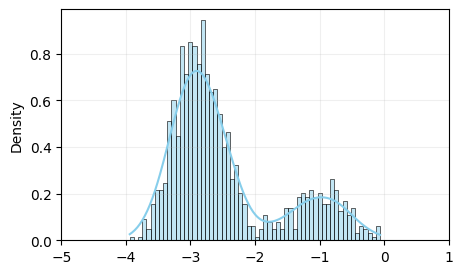

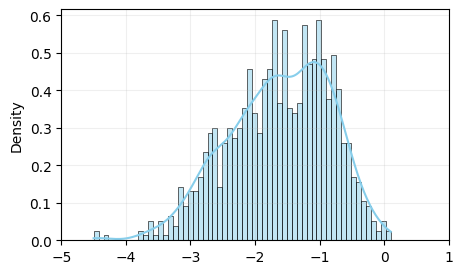

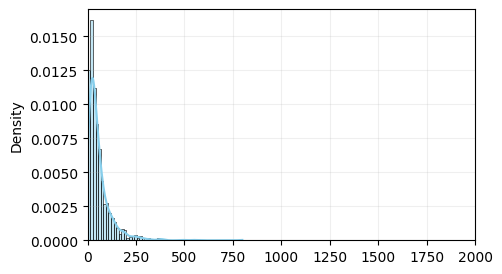

In [10]:
def visualize_samples(samples, figname, clip=[0, 1], logit_space=False):
    plt.figure(figsize=(5, 3))

    if logit_space:
        samples = logit(samples)
    sns.histplot(samples, bins=60, kde=True, stat="density", color='skyblue')

    plt.xlim(clip)

    plt.savefig(figname, format="pdf", bbox_inches="tight")
    plt.grid(alpha=0.2)
    plt.show()

ctr_data, _, cvr_data, _, wp = sample_campaign(
    seed = 1,
    sigma_ctr=1e-1,
    sigma_cvr=1e-1,
)

visualize_samples(ctr_data, f"figs/env/ctr_{len(ctr_data)}samples.pdf", clip=[-5, 1])
visualize_samples(cvr_data, f"figs/env/cvr_{len(cvr_data)}samples.pdf", clip=[-5, 1])
visualize_samples(wp, f"figs/env/wp_{len(wp)}samples.pdf", clip=[0, 2_000])

In [11]:
from experiment.non_robust_bid.offline_bidder import non_robust_bid
from experiment.denoise_bid.ctr_only.offline_bidder import denoise_bid as ctr_only_denoise_bid
# from experiment.denoise_bid.joint.offline_bidder import denoise_bid as joint_denoise_bid
from experiment.robust_bid.offline_bidder import robust_bid

from experiment.non_robust_bid.lp import solve_dual as non_robust_dual
from experiment.non_robust_bid.bid import bids as non_robust_bids

from experiment.utils.utils import logit, sigmoid

## Metrics calculation on clean environment

In [12]:
def simulate_offline_metrics(ctr_clean, cvr_clean, bids, wp, budget, target_cpc):
    is_win = bids >= wp
    total_conversions = float(np.sum(ctr_clean * cvr_clean * is_win))

    total_avg_cpc = wp.sum() / ctr_clean.sum()

    p, q = non_robust_dual(ctr_clean, cvr_clean, wp, budget, target_cpc)
    opt_bids = non_robust_bids(ctr_clean, cvr_clean, p, q, target_cpc)
    opt_value = ((opt_bids > wp) * ctr_clean * cvr_clean).sum()
    value_ratio = total_conversions / opt_value

    total_cost = float(np.sum(wp * is_win))
    total_clicks = float(np.sum(ctr_clean * is_win))
    avg_cpc = total_cost / total_clicks if total_clicks > 0 else 0.0

    avg_cpc_ratio = avg_cpc / total_avg_cpc

    return {
        "total_conversions": value_ratio,
        "avg_cpc": avg_cpc_ratio,
    }

## Experiment function

In [13]:
def run_single_experiment(
    seed: int,
    sigma_ctr: float,
    budget_proportion: float,
    target_cpc_proportion: float,
    bidder_mode: Literal["non-robust", "robust", "denoise"] = "non-robust",
    n_components=1,
):
    sigma_cvr = 0.0
    ctr_clean_logit, ctr_noised_logit, cvr_clean_logit, cvr_noised_logit, wp = sample_campaign(seed, sigma_ctr, sigma_cvr)

    ctr_clean = sigmoid(ctr_clean_logit)
    cvr_clean = sigmoid(cvr_clean_logit)
    ctr_noised = sigmoid(ctr_noised_logit)
    cvr_noised = sigmoid(cvr_noised_logit)

    budget = budget_proportion * wp.sum()
    target_cpc = target_cpc_proportion * wp.sum() / ctr_clean.sum()

    if bidder_mode == "non-robust":
        bids = non_robust_bid(ctr_noised_logit, cvr_noised_logit, wp, budget, target_cpc)
        metrics = simulate_offline_metrics(
            ctr_clean, cvr_clean, bids, wp, budget, target_cpc
        )

    elif bidder_mode == "robust":
        rob_eps = np.sum((ctr_noised - ctr_clean)**2) / 2
        bids = robust_bid(
            ctr_noised_logit,
            cvr_noised_logit,
            sigma_ctr,
            sigma_cvr,
            wp,
            budget,
            target_cpc,
            epsilon=rob_eps,
        )

        metrics = simulate_offline_metrics(
            ctr_clean, cvr_clean, bids, wp, budget, target_cpc,
        )

    elif bidder_mode == "denoise":
        bids = ctr_only_denoise_bid(
            ctr_noised_logit,
            np.ones_like(ctr_noised_logit) * sigma_ctr,
            cvr_noised_logit,
            np.ones_like(cvr_noised_logit) * sigma_cvr,
            wp,
            budget,
            target_cpc,
            n_components=n_components,
        )

        metrics = simulate_offline_metrics(
            ctr_clean, cvr_clean, bids, wp, budget, target_cpc,
        )

    return {
        "sigma": sigma_ctr,
        "seed": seed,
        "metrics": metrics,
    }

### Experiment aggregating function

In [14]:
def aggregate_results(raw_path: str, summary_path: str):
    df = pd.read_csv(raw_path)
    grouped = (
        df.groupby("sigma")
        .agg(
            total_conversions_mean=("conversions", "mean"),
            total_conversions_std=("conversions", "std"),
            avg_cpc_mean=("cpc", "mean"),
            avg_cpc_std=("cpc", "std"),
        )
        .reset_index()
    )
    grouped.to_csv(summary_path, index=False)
    return summary_path

# ALL ALGORITHMS COMPARISON

In [ ]:
SIGMAS = np.logspace(-2, 1, 10)
# NUM_SEEDS = 20  # fast run
NUM_SEEDS = 100

SEEDS = np.random.randint(0, 1_000_000_000, NUM_SEEDS)
BUDGET_PROPORTION = 0.2
TARGET_CPC_PROPORTION = 0.2

In [16]:
rows_non_robust = []
rows_robust = []
rows_normal = []
rows_2_comp = []

for sigma in tqdm(SIGMAS):
    for seed in SEEDS:
        try:
            exp_res_nr = run_single_experiment(seed, sigma, BUDGET_PROPORTION, TARGET_CPC_PROPORTION, bidder_mode="non-robust")
            exp_res_rb = run_single_experiment(seed, sigma, BUDGET_PROPORTION, TARGET_CPC_PROPORTION, bidder_mode="robust")
            exp_res_norm = run_single_experiment(seed, sigma, BUDGET_PROPORTION, TARGET_CPC_PROPORTION, bidder_mode="denoise", n_components=1)
            exp_res_gm2 = run_single_experiment(seed, sigma, BUDGET_PROPORTION, TARGET_CPC_PROPORTION, bidder_mode="denoise", n_components=2)

            rows_normal.append(
                {
                    "sigma": sigma,
                    "SEED": seed,
                    "conversions": exp_res_norm["metrics"]["total_conversions"],
                    "cpc": exp_res_norm["metrics"]["avg_cpc"],
                }
            )

            rows_2_comp.append(
                {
                    "sigma": sigma,
                    "SEED": seed,
                    "conversions": exp_res_gm2["metrics"]["total_conversions"],
                    "cpc": exp_res_gm2["metrics"]["avg_cpc"],
                }
            )

            rows_non_robust.append(
                {
                    "sigma": sigma,
                    "SEED": seed,
                    "conversions": exp_res_nr["metrics"]["total_conversions"],
                    "cpc": exp_res_nr["metrics"]["avg_cpc"],
                }
            )

            rows_robust.append(
                {
                    "sigma": sigma,
                    "SEED": seed,
                    "conversions": exp_res_rb["metrics"]["total_conversions"],
                    "cpc": exp_res_rb["metrics"]["avg_cpc"],
                }
            )
        except Exception as e:
            print(f"Error in seed {seed}, sigma {sigma}: {e}")
            continue


df_non_robust = pd.DataFrame(rows_non_robust)
df_robust = pd.DataFrame(rows_robust)
df_normal = pd.DataFrame(rows_normal)
df_2_comp = pd.DataFrame(rows_2_comp)

non_robust_all_path = f"logs/ctr_only/nr_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}.csv"
robust_all_path = f"logs/ctr_only/rb_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}.csv"
normal_all_path = f"logs/ctr_only/norm_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}.csv"
gm_2_comp_all_path = f"logs/ctr_only/gm2_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}.csv"

df_non_robust.to_csv(non_robust_all_path, index=False)
df_robust.to_csv(robust_all_path, index=False)
df_normal.to_csv(normal_all_path, index=False)
df_2_comp.to_csv(gm_2_comp_all_path, index=False)

100%|██████████| 10/10 [05:44<00:00, 34.42s/it]


In [17]:
non_robust_summary_path = f"logs/ctr_only/nr_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv"
robust_summary_path = f"logs/ctr_only/rb_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv"
normal_summary_path = f"logs/ctr_only/norm_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv"
gm_2_comp_summary_path = f"logs/ctr_only/gm2_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv"

aggregate_results(non_robust_all_path, non_robust_summary_path)
aggregate_results(robust_all_path, robust_summary_path)
aggregate_results(normal_all_path, normal_summary_path)
aggregate_results(gm_2_comp_all_path, gm_2_comp_summary_path)

'logs/ctr_only/gm2_c0.2_b0.2_summary.csv'

### *FIGURE*

In [18]:
df_list_names = [
    f"logs/ctr_only/nr_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv",
    f"logs/ctr_only/rb_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv",
    f"logs/ctr_only/norm_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv",
    f"logs/ctr_only/gm2_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv",
]

exp_num = len(df_list_names)

name_fig = f"figs/exp/ctr_only/b{BUDGET_PROPORTION}_c{TARGET_CPC_PROPORTION}.pdf"
c_arr = ["NonRobustBid", "RobustBid", "DenoiseBid (normal prior)", "DenoiseBid (2-comp prior)"]

In [19]:
metrics = [
    {
        "name": "total_conversions",
        "title": "",
        "ylabel": "$\\frac{R}{R*}$",
    },
    {
        "name": "avg_cpc",
        "title": "",
        "ylabel": "$\\frac{avg\\_CPC}{mean\\_campaign\\_CPC}$",
    },
]

dfs = []
for name in df_list_names:
    dfs.append(pd.read_csv(name))

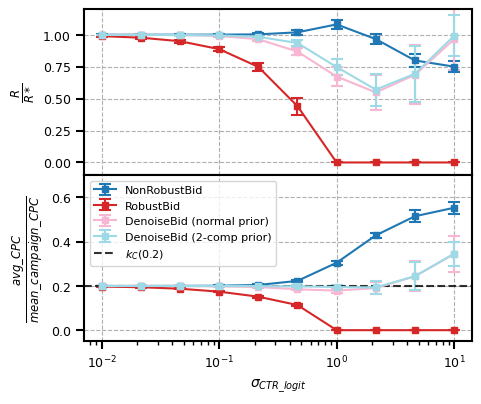

In [21]:
colors = plt.cm.tab20(np.linspace(0, 1, len(dfs)))
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    sharex=True,
    figsize=(5, 4),
    gridspec_kw=dict(hspace=0)
)

for idx, (ax, metric) in enumerate(zip(axes, metrics)):
    ax.set_xscale("log")
    ax.grid(True, linestyle="--")
    ax.set_ylabel(metric["ylabel"], fontsize=12)

    ax.tick_params(axis="both", which="major", labelsize=9, width=1.5, length=6)
    ax.tick_params(axis="both", which="minor", labelsize=9, width=1, length=3)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    for i, df in enumerate(dfs):
        ax.errorbar(
            df["sigma"],
            df[f"{metric['name']}_mean"],
            yerr=df[f"{metric['name']}_std"],
            label=f"{c_arr[i]}",
            fmt="s-",
            capsize=4,
            capthick=1.5,
            elinewidth=1.5,
            markersize=4,
            color=colors[i],
        )

axes[0].tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

axes[1].set_xlabel("$\\sigma_{CTR\\_logit}$", fontsize=10)
axes[1].axhline(TARGET_CPC_PROPORTION, c="k", alpha=0.8, label="$k_C (0.2)$", linestyle="dashed", linewidth=1.5)

axes[1].legend(frameon=True, fontsize=8, loc=2)
handles, labels = axes[1].get_legend_handles_labels()
target_label = '$k_C (0.2)$'
if target_label in labels:
    idx = labels.index(target_label)

    h = handles.pop(idx)
    l = labels.pop(idx)

    handles.append(h)
    labels.append(l)

axes[1].legend(handles, labels, frameon=True, fontsize=8, loc=2)
axes[0].set_ylim(-0.1, 1.2)
axes[1].set_ylim(-0.05, 0.7)

plt.subplots_adjust(top=0.88, bottom=0.05)
plt.savefig(name_fig, format="pdf", bbox_inches="tight")
plt.show()